In [1]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import style 
# style.use('nature.mplstyle')
# colors = ["#ebac23","#b80058","#008cf9","#006e00","#00bbad","#d163e6","#b24502","#ff9287","#5954d6","#00c6f8","#878500","#00a76c","#bdbdbd"]
colors = ["#96A2C3","#DB96C0","#E89676","#71B6A1","#ff9287","#B1AF55","#ff8234ff","#ff9287","#5954d6","#00c6f8","#878500","#00a76c","#bdbdbd"]
import scienceplots
plt.style.use(['science', 'no-latex'])

from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import r2_score
from argparse import Namespace
from ase.data import atomic_masses

sys.path.append("/home/ignaczg/projects/aramco_dac/src")
from jmp.datasets.finetune.base import LmdbDataset


In [3]:
label_keys = ['sid', 'co2_uptake', 'qst_co2']

args = Namespace(seed=0, train_samples_limit=1_000_000, val_samples_limit=-1, test_samples_limit=-1)
ara_lmdb_dir = Path("/ibex/project/c2261/datasets/aramco_mofs/output_data/test")
db1_dir = Path("/ibex/project/c2261/datasets/all-adsorption/mof_db_1/lmdb/train")
db2_dir = Path("/ibex/project/c2261/datasets/all-adsorption/mof_db_2/lmdb/test")

dfs = {}

for d, n in zip([ara_lmdb_dir, db1_dir, db2_dir], ["ara", "db1", "db2"]):
    base = LmdbDataset(
        src=str(d),
        metadata_path=str(d / "metadata.npz"),
        args=args,
        split_name="train",
    )

    results = {k: [] for k in label_keys + ["natoms", "molecular_weight"]}

    print(f"Extracting data for {n}...")
    for idx in range(len(base)):
        sample = base[idx]
        for k in label_keys:
            results[k].append(sample[k])
        
        atomic_numbers = np.asarray(sample.atomic_numbers)
        results["natoms"].append(len(atomic_numbers))
        mw = sum(atomic_masses[int(z)] for z in atomic_numbers)
        results["molecular_weight"].append(mw)

    for k in results:
        results[k] = np.array(results[k])
    dfs[n] = pd.DataFrame(results)
    dfs[n] = dfs[n][dfs[n]["co2_uptake"] > 0]

df_ara, df_db1, df_db2 = dfs["ara"], dfs["db1"], dfs["db2"]

Extracting data for ara...
Extracting data for db1...
Extracting data for db2...


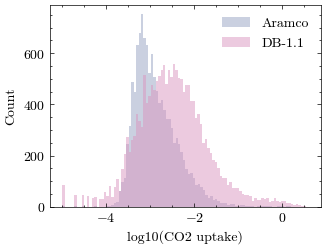

In [27]:
plt.hist(np.log10(df_ara["co2_uptake"]), bins=100, color=colors[0], alpha=0.5, label="Aramco")
plt.hist(np.log10(df_db1["co2_uptake"]), bins=100, color=colors[1], alpha=0.5, label="DB-1.1")
# plt.hist(np.log10(df_db2["co2_uptake"]), bins=100, color=colors[2])
# plt.yscale("log")
plt.xlabel("log10(CO2 uptake)")
plt.ylabel("Count")
plt.legend()
plt.savefig("temp/figures/co2_uptake_hist_db1.png", dpi=300)
plt.show()

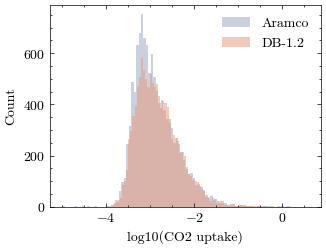

In [26]:
plt.hist(np.log10(df_ara["co2_uptake"]), bins=100, color=colors[0], alpha=0.5, label="Aramco")
# plt.hist(np.log10(df_db1["co2_uptake"]), bins=100, color=colors[1], alpha=0.5, label="DB-1.1")
plt.hist(np.log10(df_db2["co2_uptake"]), bins=100, color=colors[2], alpha=0.5, label="DB-1.2")
# plt.yscale("log")
plt.xlabel("log10(CO2 uptake)")
plt.ylabel("Count")
plt.legend()
plt.savefig("temp/figures/co2_uptake_hist_db2.png", dpi=300)
plt.show()

QST

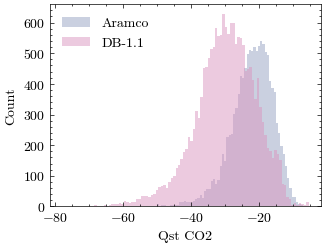

In [5]:
plt.hist(df_ara["qst_co2"], bins=100, color=colors[0], alpha=0.5, label="Aramco")
plt.hist(df_db1["qst_co2"], bins=100, color=colors[1], alpha=0.5, label="DB-1.1")
# plt.hist(np.log10(df_db2["co2_uptake"]), bins=100, color=colors[2])
# plt.yscale("log")
plt.xlabel("Qst CO2")
plt.ylabel("Count")
plt.legend()
plt.savefig("temp/figures/qst_co2_hist_db1.png", dpi=300)
plt.show()

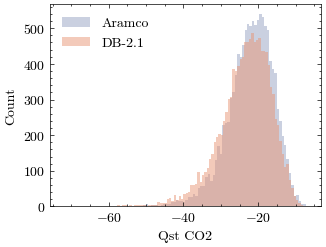

In [6]:
plt.hist(df_ara["qst_co2"], bins=100, color=colors[0], alpha=0.5, label="Aramco")
# plt.hist(df_db1["qst_co2"], bins=100, color=colors[1], alpha=0.5, label="DB-1.1")
plt.hist(df_db2["qst_co2"], bins=100, color=colors[2], alpha=0.5, label="DB-2.1")
# plt.yscale("log")
plt.xlabel("Qst CO2")
plt.ylabel("Count")
plt.legend()
plt.savefig("temp/figures/qst_co2_hist_db2.png", dpi=300)
plt.show()

# parity plots

In [7]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.style.use(['science', 'no-latex'])


def smape(x, y, eps=1e-8):
    x, y = np.array(x), np.array(y)
    denominator = (np.abs(x) + np.abs(y)) / 2.0
    return np.mean(np.abs(y - x) / (denominator + eps)) * 100

def plot_equity_with_band(ax, x, y, title, log=False, key=None, color_label=None):
    REGION_OF_INTEREST = {
        'qst_co2': [-30, -60],          # linear space
        'kh_co2':  [-3.5, 0],          # log10 exponents
        'co2_uptake': [-2, 1],          # log10 exponents
        'qst_h2o': [-40, -80],          # linear space
        'kh_h2o':  [-2, 1],             # log10 exponents
        'selectivity_co2_h2o': [0, 3],  # log10 exponents
        }
    if color_label is not None:
        colmap = {_name: i for i, _name in enumerate(np.unique(color_label))}
        ax.scatter(x, y, s=2, c=[colmap[_name] for _name in color_label], cmap='Set1')
    r2 = r2_score(x, y)

    minv, maxv = x.min(), x.max()
    ax.plot([minv, maxv], [minv, maxv], 'k--', lw=1, label="Equity line")

    if log:
        # ±0.5 log units (~ one order of magnitude band total width)
        upper = np.array([minv, maxv]) + 0.5
        lower = np.array([minv, maxv]) - 0.5
        _y = np.exp(y)
        _x = np.exp(x)
        smape_error = smape(_x, _y)

    else:
        # ±10%
        upper = 1.1 * np.array([minv, maxv])
        lower = 0.9 * np.array([minv, maxv])
        smape_error = smape(x, y)        

    ax.plot([minv, maxv], upper, 'k:', lw=0.8, label="Error bounds")
    ax.plot([minv, maxv], lower, 'k:', lw=0.8)

    # shade between bounds
    # ax.fill_between([minv, maxv], lower, upper, color="gray", alpha=0.2, label="ROI")

    # --- Count how many points fall outside shaded region ---
    # Interpolated band for each x value
    slope = (upper[1] - upper[0]) / (maxv - minv)
    upper_line = upper[0] + slope * (x - minv)
    lower_line = lower[0] + slope * (x - minv)

    outside = np.sum((y > upper_line) | (y < lower_line))

    ax.set_xlabel("Ground Truth" + (" (log10)" if log else ""))
    ax.set_ylabel("Prediction" + (" (log10)" if log else ""))
    ax.set_title(title, fontsize=10)
    if log:
        ax.text(0.05, 0.95, f"$R^2$ (log): {r2:.2f}", transform=ax.transAxes,va="top", ha="left")
        # ax.text(0.05, 0.85, f"SMAPE (norm): {smape_error:.2f}%", transform=ax.transAxes,va="top", ha="left")            
    else:
        ax.text(0.05, 0.95, f"$R^2$ (norm): {r2:.2f}", transform=ax.transAxes,va="top", ha="left")
        # ax.text(0.05, 0.85, f"SMAPE (norm): {smape_error:.2f}%", transform=ax.transAxes,va="top", ha="left")
    # if title== "Qst CO$_2$":
        # ax.text(0.05, 0.80, f"Outside ROI: {outside/len(y):.1%}", transform=ax.transAxes,
                # va="top", ha="left")
    # else:
        # ax.text(0.05, 0.80, f"Outside ROI: {(outside/len(y)):.0%}", transform=ax.transAxes,
                # va="top", ha="left")

    # --- Custom legend handles (avoid duplicates per axis) ---
    if key is not None and key in REGION_OF_INTEREST:
        # tolerate reversed intervals in your dict
        rx0, rx1 = REGION_OF_INTEREST[key]
        ry0, ry1 = REGION_OF_INTEREST[key]
        x0, x1 = (rx0, rx1) if rx0 <= rx1 else (rx1, rx0)
        y0, y1 = (ry0, ry1) if ry0 <= ry1 else (ry1, ry0)

        # shade rectangular ROI
        ax.fill_between([rx0, rx1], ry0, ry1, color="lightblue", alpha=0.15, label="ROI")
        ax.add_patch(
            plt.Rectangle((rx0, ry0), rx1 - rx0, ry1 - ry0,
                          fill=False, edgecolor="lightblue", lw=1.0, linestyle="--")
        )

        # compute on-ROI mask, count, and R2
        roi_mask = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
        in_roi = int(roi_mask.sum())
        r2_roi = np.nan
        if in_roi >= 2:
            r2_roi = r2_score(x[roi_mask], y[roi_mask])

        # annotate
        ax.text(0.05, 0.85,
                f"$R^2$ (ROI): {r2_roi:.2f}" if in_roi >= 2 else "$R^2$ (ROI): -",
                transform=ax.transAxes, va="top", ha="left")
        ax.text(0.05, 0.75,
                f"In ROI: {in_roi/len(y):.0%}",
                transform=ax.transAxes, va="top", ha="left")

    if key is not None and key in REGION_OF_INTEREST:
        roi_xmin, roi_xmax = REGION_OF_INTEREST[key]
        roi_ymin, roi_ymax = REGION_OF_INTEREST[key]
        ax.fill_between(
            [roi_xmin, roi_xmax],
            roi_ymin, roi_ymax,
            color="lightblue", alpha=0.15, label="ROI"
        )
        ax.add_patch(
            plt.Rectangle(
                (roi_xmin, roi_ymin),
                roi_xmax - roi_xmin,
                roi_ymax - roi_ymin,
                fill=False, edgecolor="lightblue", lw=1.0, linestyle="--"
            )
        )
    handles = [
        Line2D([0], [0], color='k', linestyle='--', lw=1, label='Equity'),
        Line2D([0], [0], color='k', linestyle=':', lw=0.8, label='Error bounds'),
        Patch(facecolor='lightblue', alpha=0.2, label='ROI')
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=7)



In [10]:
co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/1nujzgk7/predictions/version_1nujzgk7/final/test/adsorption_aramco/co2_uptake.npz')
# kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/ywrlm13n/predictions/version_ywrlm13n/final/val/DB1/kh_co2.npz')
qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/1nujzgk7/predictions/version_1nujzgk7/final/test/adsorption_aramco/qst_co2.npz')

In [12]:
co2_uptake

NpzFile '/ibex/project/c2261/dac_iclr/finetune/lightning_logs/1nujzgk7/predictions/version_1nujzgk7/final/test/adsorption_aramco/co2_uptake.npz' with keys: sid, gt, pred

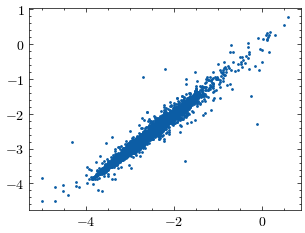

In [15]:
plt.scatter(np.log10(co2_uptake["gt"]), np.log10(co2_uptake["pred"]), s=1)
plt.show()

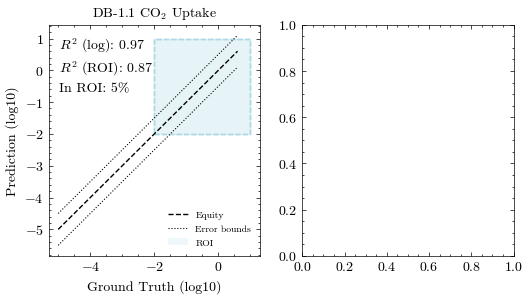

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
plot_equity_with_band(
    axes[0], 
    np.log10(co2_uptake["gt"]),
    np.log10(co2_uptake["pred"]),
    "DB-1.1 CO$_2$ Uptake",
    log=True, 
    key="co2_uptake")